### Assignment 8
Amanda Cutler
alc2282

In [90]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [91]:
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


The dataset has 716164 rows and 27 North Atlantic hurricanes.

### 1) Get the unique values of the Basin, Subbasin, and Nature columns

In [92]:
for col in ['BASIN', 'SUBBASIN', 'NATURE']:
    print (f"{col}: {df[col].unique()}")

BASIN: ['NI' 'SI' 'NA' 'EP' 'WP' 'SP' 'SA']
SUBBASIN: ['BB' 'AS' 'MM' 'GM' 'NA' 'CS' 'WA' 'EA' 'CP']
NATURE: ['NR' 'TS' 'ET' 'SS' 'MX' 'DS']


### 2) Rename the WMO_Wind and WMO_Pres columns to Wind and Pres

In [93]:
df=df.rename(columns={'WMO_WIND':'Wind', 'WMO_PRES':'Pres'})
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,Wind,Pres
0,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 03:00:00,NR,10.9000,80.3000,NaN,NaN
1,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 06:00:00,NR,10.8709,79.8265,NaN,NaN
2,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 09:00:00,NR,10.8431,79.3524,NaN,NaN
3,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 12:00:00,NR,10.8188,78.8772,NaN,NaN
4,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 15:00:00,NR,10.8000,78.4000,NaN,NaN


### 3) Get the 10 largest rows in the dataset by Wind
You will notice some names are repeated.

In [94]:
df.nlargest(10, 'Wind')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,Wind,Pres
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


### 4) Group the data on SID and get the 10 largest hurricanes by Wind.

In [95]:
gb = df.groupby('SID')
gb

In [96]:
gb.Wind.max().nlargest(10)

SID
2015293N13266    185.0
1980214N11330    165.0
1935241N23291    160.0
1988253N12306    160.0
1997253N12255    160.0
2005289N18282    160.0
2019236N10314    160.0
1998295N12284    155.0
2005261N21290    155.0
2009288N07267    155.0
Name: Wind, dtype: float64

### 5) Make a bar chart of the wind speed of the 20 strongest-wind hurricanes. 
Use the name on the x-axis.

Note: There are unnamed hurricanes in the top 20 strongest-wind hurricanes that are dropped when you use name on the x-axis.

In [118]:
gb = df.groupby('NAME')
gb

In [119]:
top20 = gb.Wind.max().nlargest(20)
top20

NAME
PATRICIA    185.0
ALLEN       165.0
DORIAN      160.0
GILBERT     160.0
LINDA       160.0
WILMA       160.0
IRMA        155.0
MITCH       155.0
RICK        155.0
RITA        155.0
ANDREW      150.0
ANITA       150.0
CAMILLE     150.0
DAVID       150.0
DEAN        150.0
FELIX       150.0
JANET       150.0
JOHN        150.0
KATRINA     150.0
MARIA       150.0
Name: Wind, dtype: float64

Text(0, 0.5, 'Wind Speed')

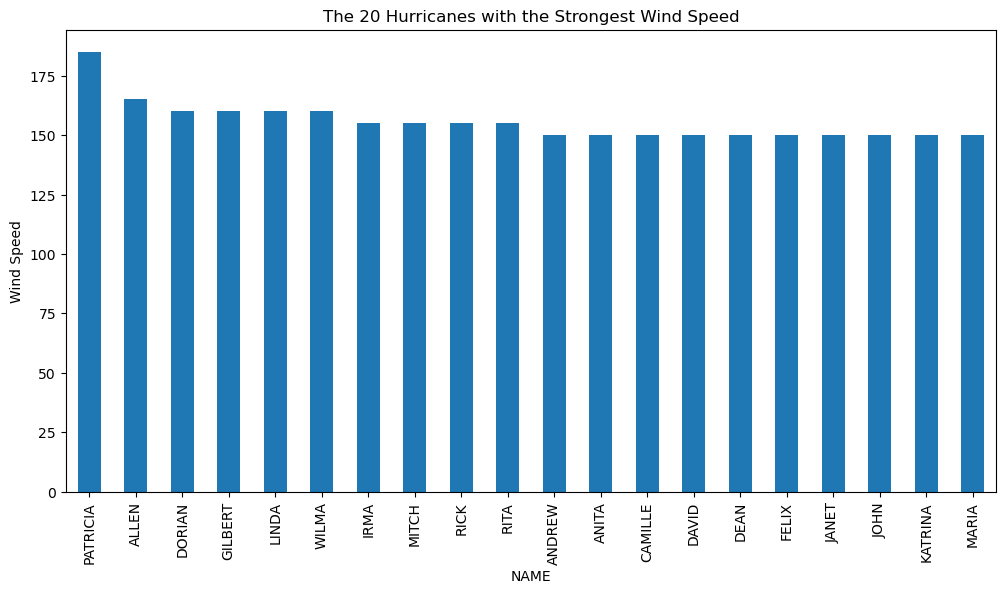

In [120]:
ax = top20.plot(kind='bar', figsize=(12,6))
ax.set_title('The 20 Hurricanes with the Strongest Wind Speed')
ax.set_ylabel('Wind Speed')

### 6) Plot the count of all datapoints by Basin as a bar chart

Text(0.5, 0, 'Basin')

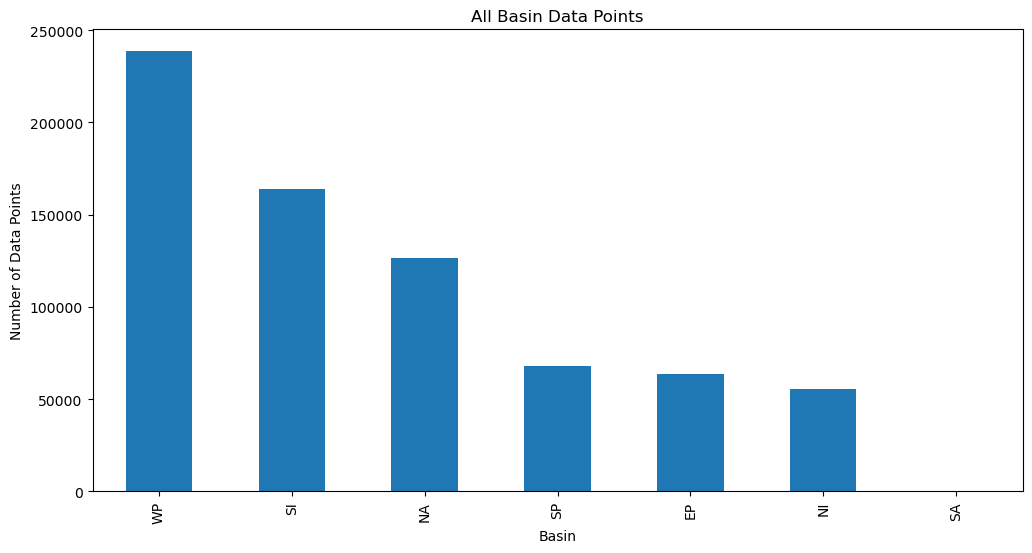

In [123]:
gb = df.groupby('BASIN')
ax = gb.SID.count().sort_values(ascending=False).plot(kind='bar',figsize=(12,6))
ax.set_title('All Basin Data Points')
ax.set_ylabel('Number of Data Points')
ax.set_xlabel('Basin')

### 7) Plot the count of unique hurricanes by Basin as a bar chart

Text(0.5, 0, 'Basin')

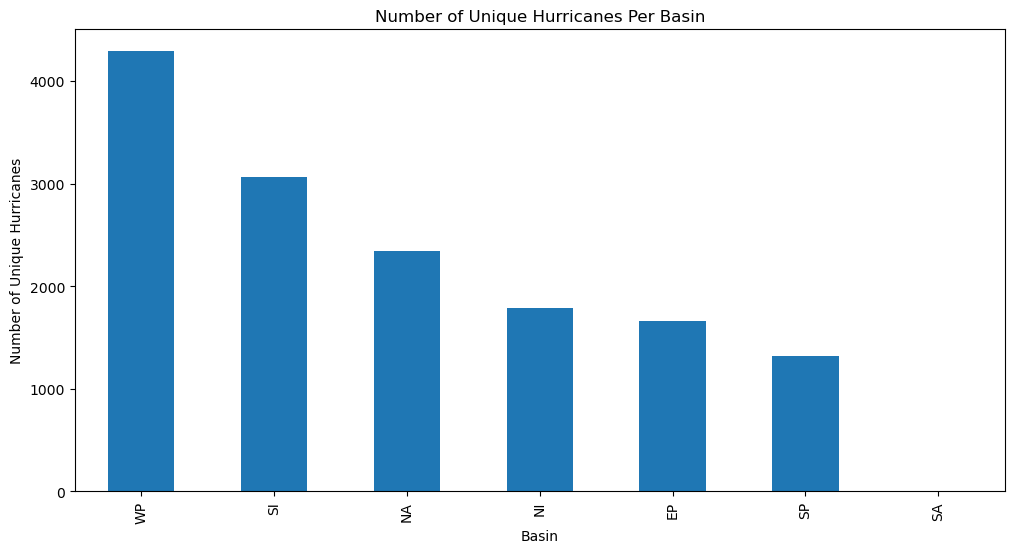

In [124]:
ax = gb.SID.nunique().sort_values(ascending=False).plot(kind='bar', figsize=(12,6))
ax.set_title('Number of Unique Hurricanes Per Basin')
ax.set_ylabel('Number of Unique Hurricanes')
ax.set_xlabel('Basin')

### 8) Make a hexbin of the location of datapoints in Latitude and Longitude

Text(0.5, 0, 'Degrees Longitude')

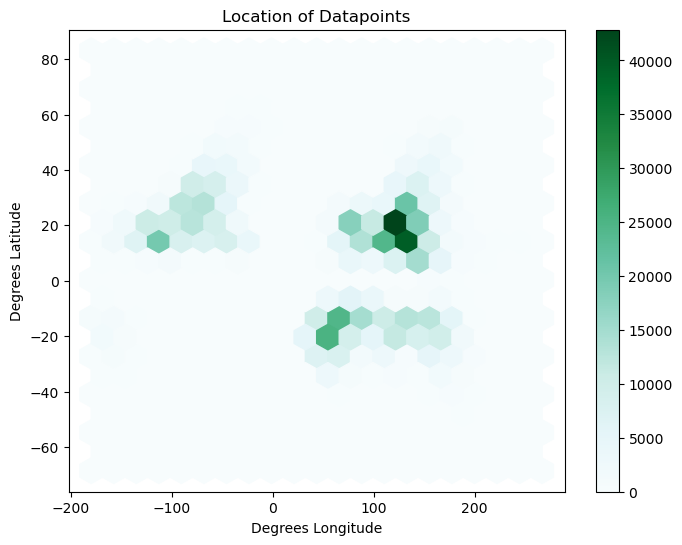

In [102]:
ax = df.plot.hexbin(x='LON', y='LAT', gridsize=20, figsize=(8,6))
ax.set_title('Location of Datapoints')
ax.set_ylabel('Degrees Latitude')
ax.set_xlabel('Degrees Longitude')

### 9) Find Hurricane Katrina (from 2005) and plot its track as a scatter plot.
First find the SID of this hurricane.
Next get this hurricane’s group and plot its position as a scatter plot. Use wind speed to color the points.

In [83]:
katrina_sid = df.loc[(df['NAME']== 'KATRINA') & (df['SEASON']==2005),'SID'].iloc[0]
katrina_sid

'2005236N23285'

In [84]:
katrina_group = df.loc[(df['SID']== katrina_sid)]
katrina_group

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,Wind,Pres
ISO_TIME,,,,,,,,,,,
2005-08-23 18:00:00,2005236N23285,2005,61,NA,NA,KATRINA,TS,23.1000,-75.1000,30.0,1008.0
2005-08-23 21:00:00,2005236N23285,2005,61,NA,NA,KATRINA,TS,23.2476,-75.4049,NaN,NaN
2005-08-24 00:00:00,2005236N23285,2005,61,NA,NA,KATRINA,TS,23.4000,-75.7000,30.0,1007.0
2005-08-24 03:00:00,2005236N23285,2005,61,NA,NA,KATRINA,TS,23.5700,-75.9726,NaN,NaN
2005-08-24 06:00:00,2005236N23285,2005,61,NA,NA,KATRINA,TS,23.8000,-76.2000,30.0,1007.0
...,...,...,...,...,...,...,...,...,...,...,...
2005-08-30 18:00:00,2005236N23285,2005,61,NA,NA,KATRINA,TS,37.0000,-87.0000,30.0,990.0
2005-08-30 21:00:00,2005236N23285,2005,61,NA,NA,KATRINA,TS,37.7916,-86.2537,NaN,NaN
2005-08-31 00:00:00,2005236N23285,2005,61,NA,NA,KATRINA,ET,38.6000,-85.3000,30.0,994.0


Text(0.5, 0, 'Longitude')

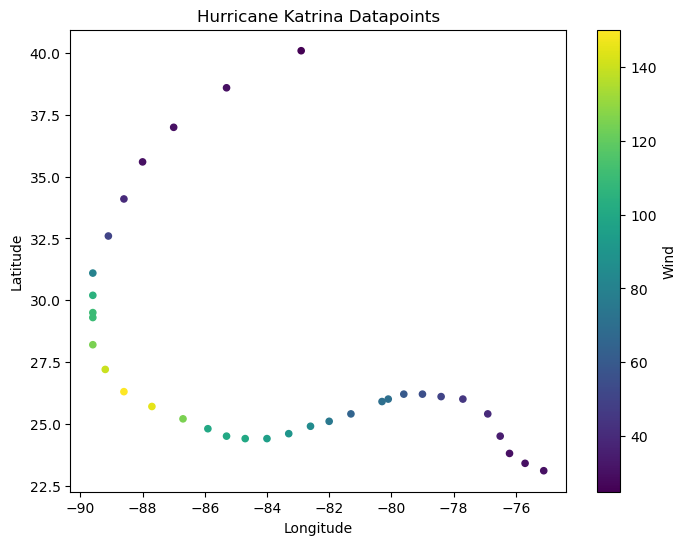

In [86]:
ax = katrina_group.plot.scatter(x='LON',y='LAT',c='Wind',figsize=(8,6))
ax.set_title('Hurricane Katrina Datapoints')
ax.set_ylabel('Latitude')
ax.set_xlabel('Longitude')

### 10) Make time the index on your dataframe

In [44]:
df=df.set_index('ISO_TIME')

### 11) Plot the count of all datapoints per year as a timeseries
You should use resample. Which years stand out as having anomalous hurricane activity?

Text(0.5, 0, 'Year')

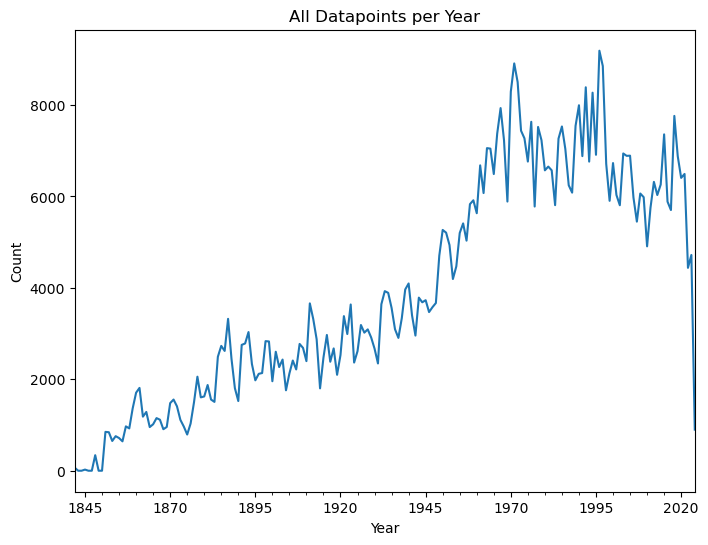

In [49]:
ax = df['SID'].resample('YE').count().plot(figsize=(8,6))
ax.set_title('All Datapoints per Year')
ax.set_ylabel('Count')
ax.set_xlabel('Year')

1970 and 1995 standout as having anomalous hurricane activity.